<a href="https://colab.research.google.com/github/Annamalag/PI_Mineria_Datos_1-/blob/main/Notebooks/02_calidad_y_limpieza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


## Notebook 02 - Calidad y Limpieza de Datos

### Objetivo

Realizar el proceso de limpieza y preparación del dataset, corrigiendo problemas de calidad como valores faltantes, categorías inconsistentes, formatos incorrectos, valores atípicos y registros inválidos para obtener un conjunto de datos confiable para el análisis exploratorio y la reducción de dimensionalidad.

## Descripción de variables del dataset

este dataset simula la base de datos de una plataforma de streaming con información de sus usuarios

| Variable | Descripción | Importancia
|---|---|---|
| `age` | Edad de la persona |
| `user_id` | Identificador único de cada usuario | Solo identifica registros |
| `subscription_plan` | Tipo de suscripción (Básico, Estándar o Premium). |  |
| `monthly_watch_time_mins` | País de residencia del usuario. |  |
| `favorite_genre` | Género de contenido preferido por el usuario. |  |
| `last_login_date` | Fecha del último acceso del usuario a la plataforma. |  |
| `customer_support_tickets` | Cantidad de consultas o reclamos realizados al soporte. |  |

In [82]:
df = pd.read_json('dataset.json')

In [83]:
print(df.shape)
print(df.head)
print(df.dtypes)


(8160, 8)
<bound method NDFrame.head of       user_id  age subscription_plan  monthly_watch_time_mins    country  \
0       10000   39          Estándar                    805.8     Brasil   
1       10001   37          Estándar                   1173.4   Colombia   
2       10002   28            Básico                    401.0   Colombia   
3       10003   43            Básico                     62.4    Uruguay   
4       10004   51            Básico                    477.8       Perú   
...       ...  ...               ...                      ...        ...   
8155    10923   23           Premium                   1161.4   Colombia   
8156    16525   27            Básico                    436.2    Uruguay   
8157    11222   13          Estándar                   1321.8     México   
8158    15613   38          Estándar                    835.7     Brasil   
8159    16912   25          Estándar                   1468.7  Argentina   

     favorite_genre last_login_date  customer_s

**Creancion una copia para evitar la perdida del data set original**

**Creamos un logs/pipeline_log.csv. para registrar cada transformacion que hagamos**

In [84]:
pipeline_log = []

In [85]:
df_limpio = df.copy()

log = []

def registrar(df_limpio,paso,descripcion):

    log.append({

        "Paso":paso,
        "Descripción":descripcion,
        "Filas":len(df_limpio),
        "Nulos":df_limpio.isnull().sum().sum()

    })

registrar(df_limpio,0,"Dataset original")

## **Datos duplicados**

In [86]:
df_limpio.duplicated().sum()

np.int64(126)

In [87]:
df_limpio = df_limpio.drop_duplicates()

In [88]:
df_limpio.duplicated().sum()

np.int64(0)

In [89]:
registrar(df_limpio,1,"Duplicados")

Evidencia: Se detectaron registros duplicados mediante duplicated().

Acción:Se eliminaron utilizando drop_duplicates().

Impacto:Se evitó contabilizar varias veces un mismo usuario

## **Correcion de planes**

In [90]:
df_limpio["subscription_plan"].value_counts()

,count
subscription_plan,
Básico,3395
Estándar,2669
Premium,1490
basico,60
BASICO,52
Basic,52
básico,50
Std,48
Estándar,46


In [91]:
mapa_plan = {

    "Std":"Estándar",
    "estandar":"Estandar",
    "Estándar":"Estandar",
    "STANDARD":"Estandar",
    "Std":"Estandar",


    "basico":"Basico",
    "básico":"Basico",
    "Básico":"Basico",
    "BASICO":"Basico",
    "Basic": "Basico",

    "Premium":"Premium",
    "Premium":"Premium",
    "PREMIUM":"Premium",
    "Premiun":"Premium",
    "premium": "Premium",


}

df_limpio["subscription_plan"] = (
    df_limpio["subscription_plan"]
    .str.strip()
    .replace(mapa_plan)
)

In [92]:
df_limpio["subscription_plan"].value_counts()

,count
subscription_plan,
Basico,3609
Estandar,2833
Premium,1592


In [93]:
registrar(df_limpio,2,"Normalización de subscription_plan")

# **PAISES**

In [94]:
df_limpio["country"].value_counts()

,count
country,
Chile,1118
Brasil,1115
México,1106
Uruguay,1105
Colombia,1099
Perú,1096
Argentina,1075
colombia,27
méxico,25


In [95]:
mapa_country = {

    "Brazil":"Brasil",
    "brasil":"Brasil",
    "Brasil":"Brasil",
    "BRA":"Brasil",

    "méxico":"Mexico",
    "México":"Mexico",
    "MEX":"Mexico",
    "Mexico":"Mexico",


    "chile":"Chile",
    "CHL":"Chile",
    "Chile":"Chile",


    "uruguay":"Uruguay",
    "URY":"Uruguay",
    "Uruguay":"Uruguay",

    "argentina":"Argentina",
    "ARG":"Argentina",
    "Argentina":"Argentina",

    "colombia":"Colombia",
    "COL":"Colombia",
    "Colombia":"Colombia",

    "Peru":"Peru",
    "Perú":"Peru",
    "PER":"Peru",
    "perú":"Peru"


}

df_limpio["country"] = (
    df_limpio["country"]
    .str.strip()
    .replace(mapa_country)
)

In [96]:
df_limpio["country"].value_counts()

,count
country,
Chile,1167
Brasil,1164
Mexico,1162
Uruguay,1146
Colombia,1145
Peru,1139
Argentina,1111


In [97]:
registrar(df_limpio,3,"Normalización de países")

# **GENERO**

In [98]:
df_limpio["favorite_genre"].value_counts(dropna=False)

,count
favorite_genre,
Comedia,1095
Drama,1088
Thriller,1077
Documental,1070
Romance,1070
Acción,1066
Crime,1049
None,240
Action,22


In [99]:
df_limpio["favorite_genre"] = (
    df_limpio["favorite_genre"]
    .str.strip()
    .str.title()
)

mapa_genero = {

    "Accion":"Acción",
    "Comedy":"Comedia",
    "Documentary":"Documental",
    "Acción":"Accion",
    "Action":"Accion",
    "Accion":"Accion",
    "Comedia":"Comedia",
    "Doc":"Documental",
    "Drama":"Drama",
    "Crime":"Crimen",
    "Crimen":"Crimen",
    "Thriller":"Thriller",
    "Thriler":"Thriller",

    "Romance":"Romance",

}

df_limpio["favorite_genre"] = df_limpio["favorite_genre"].replace(mapa_genero)

In [100]:
df_limpio["favorite_genre"].value_counts()

,count
favorite_genre,
Comedia,1141
Drama,1121
Romance,1113
Documental,1111
Accion,1110
Thriller,1109
Crimen,1089


In [101]:
df_limpio["favorite_genre"].unique()

array(['Crimen', 'Thriller', 'Drama', 'Accion', 'Romance', 'Comedia',
       'Documental', None], dtype=object)

In [102]:
registrar(df_limpio,4,"Normalización de géneros")

# **datos nulos**

In [103]:
df_limpio.isnull().sum()

,0
user_id,0
age,0
subscription_plan,0
monthly_watch_time_mins,193
country,0
favorite_genre,240
last_login_date,320
customer_support_tickets,0


**Elinimos espacios en blanco**

In [104]:
columnas_texto = ["subscription_plan","country","favorite_genre"]

for col in columnas_texto:
    df_limpio[col] = df_limpio[col].str.strip()

**Normalizamos las mayuculas y minusculas**

In [105]:
for col in columnas_texto:
    df_limpio[col] = df_limpio[col].str.lower()

In [106]:
for col in columnas_texto:
    df_limpio[col] = df_limpio[col].str.capitalize()

Aqui vemos la edad, filtramos y eliminamos edades imposibles



In [107]:
df_limpio["age"].describe().round(2)

,age
count,8034.00
mean,34.10
std,14.56
min,-5.00
25%,25.00
50%,33.00
75%,42.00
max,150.00


# **EDAD**

In [108]:
df_limpio[df_limpio["age"]<13]

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
49,10049,0,Basico,1081.6,Argentina,Romance,2023-02-25,0
310,10310,0,Estandar,877.9,Peru,Crimen,2025-06-04,0
442,10442,-5,Estandar,1693.0,Mexico,Crimen,2022-10-27,0
573,10573,-5,Premium,1129.5,Peru,Documental,2023-04-23,1
1126,11126,0,Premium,-1.0,Colombia,Documental,2021-01-24,1
...,...,...,...,...,...,...,...,...
7686,17686,4,Estandar,1024.9,Colombia,Crimen,2024-04-27,0
7790,17790,-5,Basico,1009.7,Brasil,Accion,2024-07-20,1
7812,17812,0,Basico,910.7,Argentina,Documental,2023-11-22,2
7927,17927,0,Premium,911.0,Peru,Drama,2022-01-10,1


In [109]:
df_limpio[df_limpio["age"]>100]

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
194,10194,130,Basico,820.7,Uruguay,Drama,2018-10-11,1
324,10324,130,Basico,420.8,Brasil,Thriller,2023-05-07,1
426,10426,150,Premium,1315.6,Colombia,Accion,2022-12-15,1
529,10529,130,Basico,590.1,Uruguay,Thriller,2018-10-14,0
640,10640,150,Premium,1374.6,Argentina,Drama,2025-02-24,2
655,10655,130,Premium,1097.5,Chile,Documental,2018-11-27,0
751,10751,150,Basico,167.4,Chile,Accion,2019-04-14,0
1028,11028,150,Basico,302.7,Argentina,Accion,2018-06-13,1
1099,11099,150,Basico,771.3,Peru,Romance,2021-03-25,-1
1374,11374,130,Basico,NaN,Uruguay,Accion,2024-04-18,0


In [110]:
df_limpio.loc[(df_limpio.age<13)|(df_limpio.age>100),"age"]=np.nan

In [111]:

mediana_edad = df_limpio["age"].median()
print(mediana_edad)

33.0


In [112]:
df_limpio["age"]=df_limpio["age"].fillna(df_limpio["age"].median())

In [113]:
df_limpio.loc[(df_limpio['age'] < 13) | (df_limpio['age'] > 100), 'age'] = mediana_edad

In [114]:
df_limpio['age'].describe().round(2)

,age
count,8034.00
mean,33.69
std,11.46
min,13.00
25%,26.00
50%,33.00
75%,41.00
max,80.00


In [115]:
registrar(df,5,"Edad fuera de rango corregida con la mediana")

Se utilizo la mediana (33 años)para corregir el tema de las edades imposible y ahora segun mi percepcion la variable age quedó dentro de un rango coherente para el análisis

# **Tiempo de visualización**

In [116]:
df_limpio["monthly_watch_time_mins"].describe().round()

,monthly_watch_time_mins
count,7841.0
mean,1112.0
std,5353.0
min,-120.0
25%,488.0
50%,757.0
75%,1044.0
max,99999.0


<Axes: xlabel='monthly_watch_time_mins'>

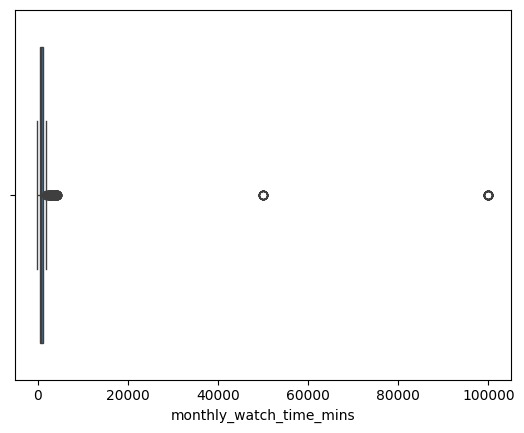

In [117]:
sns.boxplot(x=df_limpio["monthly_watch_time_mins"])

In [118]:
df_limpio.loc[
    df_limpio["monthly_watch_time_mins"]>10000,
    "monthly_watch_time_mins"
]=np.nan

**VALORES ATIPICOS**

In [119]:
Q1 = df_limpio["monthly_watch_time_mins"].quantile(0.25)
Q3 = df_limpio["monthly_watch_time_mins"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = (
    (df_limpio["monthly_watch_time_mins"] < lim_inf) |
    (df_limpio["monthly_watch_time_mins"] > lim_sup)
)

print("Cantidad de outliers:", outliers.sum())
print(f"Limite inferior: {lim_inf}")
print(f"Limite superior: {lim_sup}")

df_limpio.loc[outliers, "monthly_watch_time_mins"] = np.nan

Cantidad de outliers: 123
Limite inferior: -342.7750000000002
Limite superior: 1871.0250000000003


In [133]:
df_limpio["monthly_watch_time_mins"] = df_limpio["monthly_watch_time_mins"].fillna(
    df_limpio["monthly_watch_time_mins"].median()
)

In [134]:
print("Outliers eliminados:", outliers.sum())

Outliers eliminados: 123


In [135]:
registrar(df_limpio,6,"Tiempo de visualización corregida con la mediana")

Aplique el método del Rango Intercuartílico (IQR) para detectar valores atípicos en la variable **monthly_watch_time_mins**. Se observaron registros con tiempos de visualización muy superiores al comportamiento general del conjunto de datos.
calcule los límites mediante:

Limite inferior=Q1−1.5×IQR

Lmite superior=Q3+1.5×IQR

Los valores fuera de esos límites se reemplazaron por valores nulos (NaN) y posteriormente se imputaron con la mediana de la variable para preservar los registros.

Corregimos fechaas convirtiendolas en "datatime"

In [136]:
df_limpio["last_login_date"].sample(10)

,last_login_date
1240,2023-12-16
3084,2025-02-21
4297,2025-09-15
625,2023-12-16
4701,2021-09-19
4345,2024-05-30
1386,2019-04-23
4184,2018-06-05
4671,2025-12-31
7680,2021-03-30


In [124]:
df_limpio["last_login_date"] = pd.to_datetime(
    df_limpio["last_login_date"],
    errors="coerce",
    format="mixed"
)

In [125]:
df_limpio.dtypes

,0
user_id,int64
age,float64
subscription_plan,object
monthly_watch_time_mins,float64
country,object
favorite_genre,object
last_login_date,datetime64[ns]
customer_support_tickets,int64


In [126]:
hoy = pd.Timestamp.today()

df_limpio.loc[
    df_limpio["last_login_date"]>hoy,
    "last_login_date"
]=pd.NaT
print(hoy)

2026-07-01 17:43:26.173558


In [127]:
registrar(df_limpio,7,"Conversión de fechas")

Los valores faltantes de las fechas inválidas se conservaron como NaT, ya que no encontre un criterio objetivo para reemplazarlas/imputarla

No utilice la moda porque utilizar una misma fecha para distintos usuarios(320) , haria que los datos se concentren en una sola fecha, y la mediana probablemente no represente el real comportamiento de los usuarios. ambas opcion creo que podrian podrucir un sesgo entre los usuarios.
igualmente los valores faltantes solo repesentan el 3.93% de los datos, aunque es un valor bajo dentro del dataset, eliminarlos haria perder informacion de las demas variables.

In [137]:
df_limpio.isnull().sum()

,0
user_id,0
age,0
subscription_plan,0
monthly_watch_time_mins,0
country,0
favorite_genre,0
last_login_date,399
customer_support_tickets,0


In [138]:
fechas_invalidas = df_limpio[df_limpio["last_login_date"].isna()]["last_login_date"]
print(f"Cantidad de fechas inválidas: {len(fechas_invalidas)}")
print(fechas_invalidas.unique())

Cantidad de fechas inválidas: 399
<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]


# **favorite_genre**

In [139]:
moda_genre = df_limpio["favorite_genre"].mode()[0]

df_limpio["favorite_genre"] = df_limpio["favorite_genre"].fillna(moda_genre)

In [140]:
registrar(df_limpio,8,"Utilizacion de la moda en genero favorito")

In [141]:
df_limpio.isnull().sum()

,0
user_id,0
age,0
subscription_plan,0
monthly_watch_time_mins,0
country,0
favorite_genre,0
last_login_date,399
customer_support_tickets,0


La variable **favorite_genre** es de tipo categórica nominal, use la moda para imputar los valores faltantes  ya que representa la categoría más frecuente del conjunto de datos.

In [142]:
# ==============================
# RESUMEN FINAL DEL PIPELINE
# ==============================

log_df_limpio = pd.DataFrame(log)

print("\n========== LOG DEL PIPELINE ==========")
print(log_df_limpio.to_string(index=False))

# Calculate correct metrics for the summary
original_rows = len(df)
final_rows = len(df_limpio)
duplicates_removed_count = original_rows - final_rows
retention_percentage = final_rows / original_rows * 100

print("\n========== MÉTRICAS FINALES ==========")

print(f"Filas originales             : {original_rows}")
print(f"Filas finales                : {final_rows}")
print(f"Retención del dataset        : {retention_percentage:.2f}%")

print(f"Duplicados eliminados        : {duplicates_removed_count}")

print(f"Outliers corregidos          : {outliers.sum()}")

print(f"Nulos finales               : {df_limpio.isnull().sum().sum()}")

print("\nPlanes de suscripción:")
print(df_limpio["subscription_plan"].unique())

print("\nPaíses:")
print(df_limpio["country"].unique())

print("\nGéneros:")
print(df_limpio["favorite_genre"].unique())


========== LOG DEL PIPELINE ==========
 Paso                                      Descripción  Filas  Nulos
    0                                 Dataset original   8160    753
    1                                       Duplicados   8034    753
    2               Normalización de subscription_plan   8034    753
    3                          Normalización de países   8034    753
    4                         Normalización de géneros   8034    753
    5     Edad fuera de rango corregida con la mediana   8160    753
    6 Tiempo de visualización corregida con la mediana   8034    907
    7                             Conversión de fechas   8034    986
    8        Utilizacion de la moda en genero favorito   8034    746
    6 Tiempo de visualización corregida con la mediana   8034    399
    8        Utilizacion de la moda en genero favorito   8034    399

========== MÉTRICAS FINALES ==========
Filas originales             : 8160
Filas finales                : 8034
Retención del datase

## Conclusiones

Se realizó un proceso completo de limpieza y preparación de los datos.

Las principales transformaciones fueron:

- Eliminación de espacios innecesarios.
- Unificación de categorías.
- Corrección de formatos de fechas.
- Eliminación de edades inválidas.
- Tratamiento de valores atípicos mediante IQR.
- Imputación de valores faltantes.
- Generación del dataset limpio para las siguientes etapas del proyecto.

El conjunto de datos obtenido presenta una estructura consistente y adecuada para el análisis exploratorio y la aplicación de PCA.